# Análisis de la Carga de Enfermedades No Transmisibles en América Latina (1990–2021)

**Autora:** María Fernanda Ramírez Serrano  
**Curso:** Herramientas Básicas para el Análisis de Datos - UTN BA  
**Dataset:** Global Burden of Disease Study 2023 (IHME)  

## Objetivo
Analizar la evolución de la carga de ENT medida en DALYs en América Latina entre 1990 y 2021, identificando las enfermedades con mayor impacto y las tendencias regionales.

In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente ✓")

Librerías importadas correctamente ✓


In [2]:
# Carga de archivos desde tu computadora
from google.colab import files

print("Seleccioná los 3 archivos CSV cuando aparezca el selector")
uploaded = files.upload()

Seleccioná los 3 archivos CSV cuando aparezca el selector


Saving IHME-GBD_2023_DATA-0ee1ed6d-1.csv to IHME-GBD_2023_DATA-0ee1ed6d-1.csv
Saving IHME-GBD_2023_DATA-83c77c4d-1.csv to IHME-GBD_2023_DATA-83c77c4d-1.csv
Saving IHME-GBD_2023_DATA-48939b37-1.csv to IHME-GBD_2023_DATA-48939b37-1.csv


In [3]:
# Unión de los tres archivos CSV en un solo DataFrame
import io

# Leer cada archivo y unirlos
dfs = []
for nombre, contenido in uploaded.items():
    df_temp = pd.read_csv(io.BytesIO(contenido))
    print(f"Archivo: {nombre} → {df_temp.shape[0]} filas, {df_temp.shape[1]} columnas")
    dfs.append(df_temp)

# Concatenar todos los archivos
df = pd.concat(dfs, ignore_index=True)

print(f"\n✓ Dataset unificado: {df.shape[0]} filas y {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Archivo: IHME-GBD_2023_DATA-0ee1ed6d-1.csv → 704 filas, 18 columnas
Archivo: IHME-GBD_2023_DATA-83c77c4d-1.csv → 4480 filas, 18 columnas
Archivo: IHME-GBD_2023_DATA-48939b37-1.csv → 5376 filas, 18 columnas

✓ Dataset unificado: 10560 filas y 18 columnas

Columnas disponibles:
['population_group_id', 'population_group_name', 'measure_id', 'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name', 'age_id', 'age_name', 'cause_id', 'cause_name', 'metric_id', 'metric_name', 'year', 'val', 'upper', 'lower']


In [4]:
# ============================================
# AUDITORÍA DE DATOS
# ============================================

print("=" * 50)
print("1. PRIMERAS FILAS DEL DATASET")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("2. TIPOS DE DATOS")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("3. VALORES NULOS POR COLUMNA")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("4. DUPLICADOS")
print("=" * 50)
print(f"Filas duplicadas: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("5. ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
display(df.describe())

print("\n" + "=" * 50)
print("6. VALORES ÚNICOS EN COLUMNAS CLAVE")
print("=" * 50)
print(f"Países: {df['location_name'].nunique()} → {df['location_name'].unique().tolist()}")
print(f"Causas: {df['cause_name'].nunique()} → {df['cause_name'].unique().tolist()}")
print(f"Años: {df['year'].min()} a {df['year'].max()}")
print(f"Métricas: {df['metric_name'].unique().tolist()}")

1. PRIMERAS FILAS DEL DATASET


,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,Toda la población,2,AVISA (Años de Vida Saludable Perdidos),130,México,3,Ambos,22,Todas las edades,409,Enfermedades que no son contagiosas,1,Número,1990,1.397795e+07,1.569227e+07,1.247018e+07
1,1,Toda la población,2,AVISA (Años de Vida Saludable Perdidos),130,México,3,Ambos,22,Todas las edades,409,Enfermedades que no son contagiosas,3,Tasa,1990,1.640108e+04,1.841258e+04,1.463193e+04
2,1,Toda la población,2,AVISA (Años de Vida Saludable Perdidos),97,Argentina,3,Ambos,22,Todas las edades,409,Enfermedades que no son contagiosas,1,Número,1990,7.909247e+06,8.678364e+06,7.197873e+06
3,1,Toda la población,2,AVISA (Años de Vida Saludable Perdidos),97,Argentina,3,Ambos,22,Todas las edades,409,Enfermedades que no son contagiosas,3,Tasa,1990,2.378527e+04,2.609821e+04,2.164597e+04
4,1,Toda la población,2,AVISA (Años de Vida Saludable Perdidos),121,Bolivia,3,Ambos,22,Todas las edades,409,Enfermedades que no son contagiosas,1,Número,1990,1.275600e+06,1.430010e+06,1.126197e+06



2. TIPOS DE DATOS
population_group_id        int64
population_group_name     object
measure_id                 int64
measure_name              object
location_id                int64
location_name             object
sex_id                     int64
sex_name                  object
age_id                     int64
age_name                  object
cause_id                   int64
cause_name                object
metric_id                  int64
metric_name               object
year                       int64
val                      float64
upper                    float64
lower                    float64
dtype: object

3. VALORES NULOS POR COLUMNA
population_group_id      0
population_group_name    0
measure_id               0
measure_name             0
location_id              0
location_name            0
sex_id                   0
sex_name                 0
age_id                   0
age_name                 0
cause_id                 0
cause_name               0
metric_id          

,population_group_id,measure_id,location_id,sex_id,age_id,cause_id,metric_id,year,val,upper,lower
count,10560.0,10560.0,10560.000000,10560.0,10560.0,10560.000000,10560.000000,10560.00000,1.056000e+04,1.056000e+04,1.056000e+04
mean,1.0,2.0,119.909091,3.0,22.0,593.066667,2.000000,2005.50000,7.777818e+05,8.750047e+05,6.927837e+05
std,0.0,0.0,14.280061,0.0,0.0,144.596135,1.000047,9.23353,3.573505e+06,4.030626e+06,3.178766e+06
min,1.0,2.0,97.000000,3.0,22.0,409.000000,1.000000,1990.00000,5.173676e+00,6.102982e+00,4.056440e+00
25%,1.0,2.0,99.000000,3.0,22.0,491.000000,1.000000,1997.75000,1.014761e+03,1.194480e+03,8.329486e+02
50%,1.0,2.0,123.000000,3.0,22.0,603.000000,2.000000,2005.50000,1.596746e+04,1.861573e+04,1.376728e+04
75%,1.0,2.0,133.000000,3.0,22.0,689.000000,3.000000,2013.25000,2.140176e+05,2.535324e+05,1.880772e+05
max,1.0,2.0,136.000000,3.0,22.0,974.000000,3.000000,2021.00000,4.889712e+07,5.554465e+07,4.320732e+07



6. VALORES ÚNICOS EN COLUMNAS CLAVE
Países: 11 → ['México', 'Argentina', 'Bolivia', 'Uruguay', 'Perú', 'Venezuela', 'Brasil', 'Chile', 'Paraguay', 'Colombia', 'Ecuador']
Causas: 14 → ['Enfermedades que no son contagiosas', 'Síndrome de muerte súbita del lactante', 'Accidentes de tránsito', 'Caídas', 'Ahogamientos', 'Enfermedades digestivas', 'Neoplasias', 'Diabetes y enfermedades renales', 'Trastornos neurolágicos', 'Enfermedades respiratorias crónicas', 'Anomalías congénitas', 'Enfermedades cardiovasculares', 'Enfermedades ginecológicas', 'Hemoglobinopatías y anemias hemolíticos']
Años: 1990 a 2021
Métricas: ['Número', 'Tasa']


In [5]:
# ============================================
# LIMPIEZA Y ESTANDARIZACIÓN
# ============================================

# Eliminar duplicados
df = df.drop_duplicates()
print(f"✓ Duplicados eliminados. Filas restantes: {df.shape[0]}")

# Seleccionar solo columnas útiles para el análisis
df = df[['location_name', 'cause_name', 'metric_name',
         'sex_name', 'age_name', 'year', 'val', 'upper', 'lower']]

# Renombrar columnas al español para mayor claridad
df.columns = ['pais', 'causa', 'metrica', 'sexo', 'edad', 'anio',
              'valor', 'limite_superior', 'limite_inferior']

# Filtrar solo la métrica Número para análisis de volumen
# y Tasa para comparaciones entre países
print(f"\n✓ Métricas disponibles: {df['metrica'].unique().tolist()}")

# Verificar resultado final
print(f"\n✓ Dataset limpio: {df.shape[0]} filas y {df.shape[1]} columnas")
print("\nPrimeras filas del dataset limpio:")
display(df.head(10))

✓ Duplicados eliminados. Filas restantes: 9856

✓ Métricas disponibles: ['Número', 'Tasa']

✓ Dataset limpio: 9856 filas y 9 columnas

Primeras filas del dataset limpio:


,pais,causa,metrica,sexo,edad,anio,valor,limite_superior,limite_inferior
0,México,Enfermedades que no son contagiosas,Número,Ambos,Todas las edades,1990,1.397795e+07,1.569227e+07,1.247018e+07
1,México,Enfermedades que no son contagiosas,Tasa,Ambos,Todas las edades,1990,1.640108e+04,1.841258e+04,1.463193e+04
2,Argentina,Enfermedades que no son contagiosas,Número,Ambos,Todas las edades,1990,7.909247e+06,8.678364e+06,7.197873e+06
3,Argentina,Enfermedades que no son contagiosas,Tasa,Ambos,Todas las edades,1990,2.378527e+04,2.609821e+04,2.164597e+04
4,Bolivia,Enfermedades que no son contagiosas,Número,Ambos,Todas las edades,1990,1.275600e+06,1.430010e+06,1.126197e+06
5,Bolivia,Enfermedades que no son contagiosas,Tasa,Ambos,Todas las edades,1990,1.995011e+04,2.236506e+04,1.761348e+04
6,Uruguay,Enfermedades que no son contagiosas,Número,Ambos,Todas las edades,1990,8.500747e+05,9.279771e+05,7.784660e+05
7,Uruguay,Enfermedades que no son contagiosas,Tasa,Ambos,Todas las edades,1990,2.695275e+04,2.942275e+04,2.468230e+04
8,Perú,Enfermedades que no son contagiosas,Número,Ambos,Todas las edades,1990,3.408980e+06,3.900978e+06,2.977046e+06
9,Perú,Enfermedades que no son contagiosas,Tasa,Ambos,Todas las edades,1990,1.568072e+04,1.794383e+04,1.369390e+04


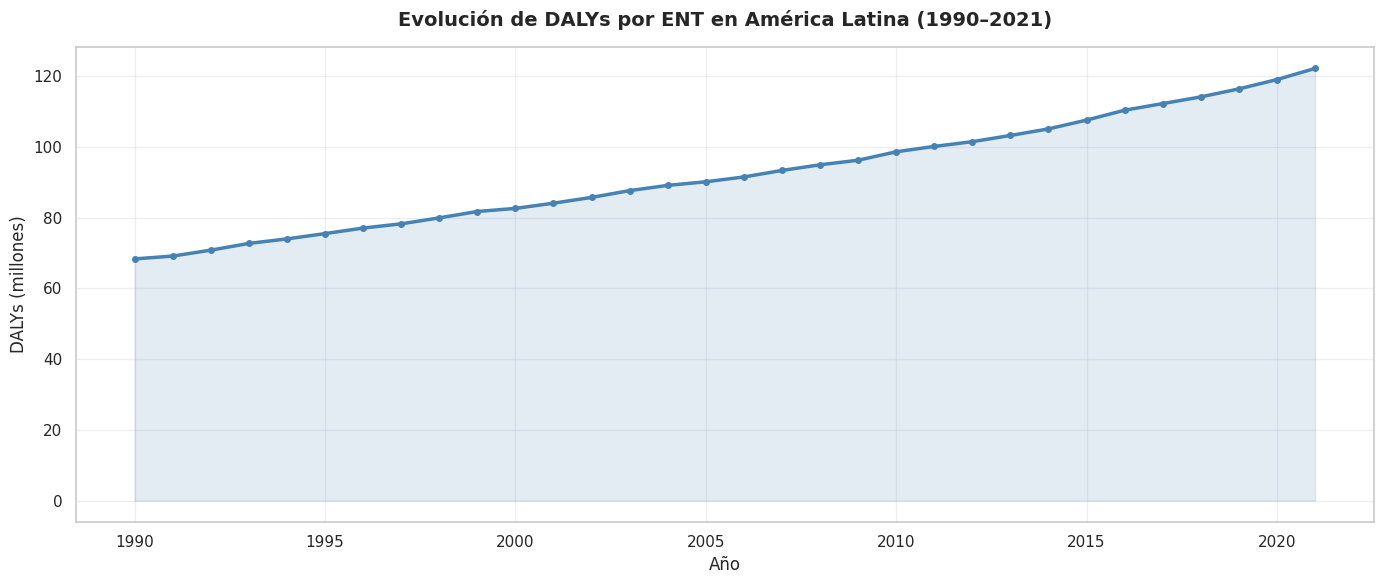


Interpretación: Este gráfico muestra la tendencia total de DALYs
por ENT en América Latina entre 1990 y 2021.


In [6]:
# ============================================
# GRÁFICO 1: Evolución temporal de DALYs en LATAM
# ============================================

# Filtrar solo DALYs en Número y causa general ENT
df_evol = df[
    (df['metrica'] == 'Número') &
    (df['causa'] == 'Enfermedades que no son contagiosas')
].groupby('anio')['valor'].sum().reset_index()

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_evol['anio'], df_evol['valor'] / 1_000_000,
        color='steelblue', linewidth=2.5, marker='o', markersize=4)

ax.set_title('Evolución de DALYs por ENT en América Latina (1990–2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('DALYs (millones)', fontsize=12)
ax.fill_between(df_evol['anio'], df_evol['valor'] / 1_000_000,
                alpha=0.15, color='steelblue')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico1_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación: Este gráfico muestra la tendencia total de DALYs")
print("por ENT en América Latina entre 1990 y 2021.")

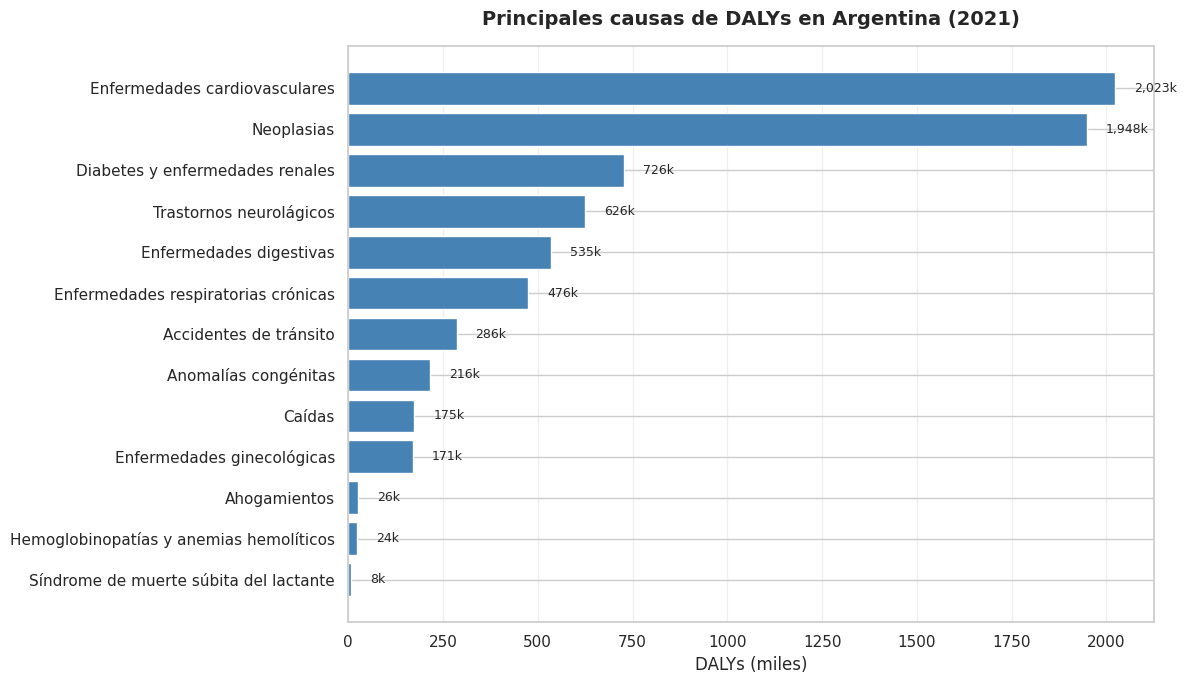


Interpretación: Las enfermedades cardiovasculares y las neoplasias
concentran la mayor carga de ENT en Argentina en 2021.


In [7]:
# ============================================
# GRÁFICO 2: Top ENT en Argentina 2021
# ============================================

# Filtrar Argentina, año 2021, métrica Número, sin la categoría general
df_arg = df[
    (df['pais'] == 'Argentina') &
    (df['anio'] == 2021) &
    (df['metrica'] == 'Número') &
    (df['causa'] != 'Enfermedades que no son contagiosas')
].groupby('causa')['valor'].sum().reset_index()

# Ordenar de mayor a menor
df_arg = df_arg.sort_values('valor', ascending=True)

# Graficar
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_arg['causa'], df_arg['valor'] / 1_000,
               color='steelblue', edgecolor='white')

# Agregar valores en las barras
for bar, val in zip(bars, df_arg['valor'] / 1_000):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}k', va='center', fontsize=9)

ax.set_title('Principales causas de DALYs en Argentina (2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('DALYs (miles)', fontsize=12)
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico2_argentina_2021.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación: Las enfermedades cardiovasculares y las neoplasias")
print("concentran la mayor carga de ENT en Argentina en 2021.")

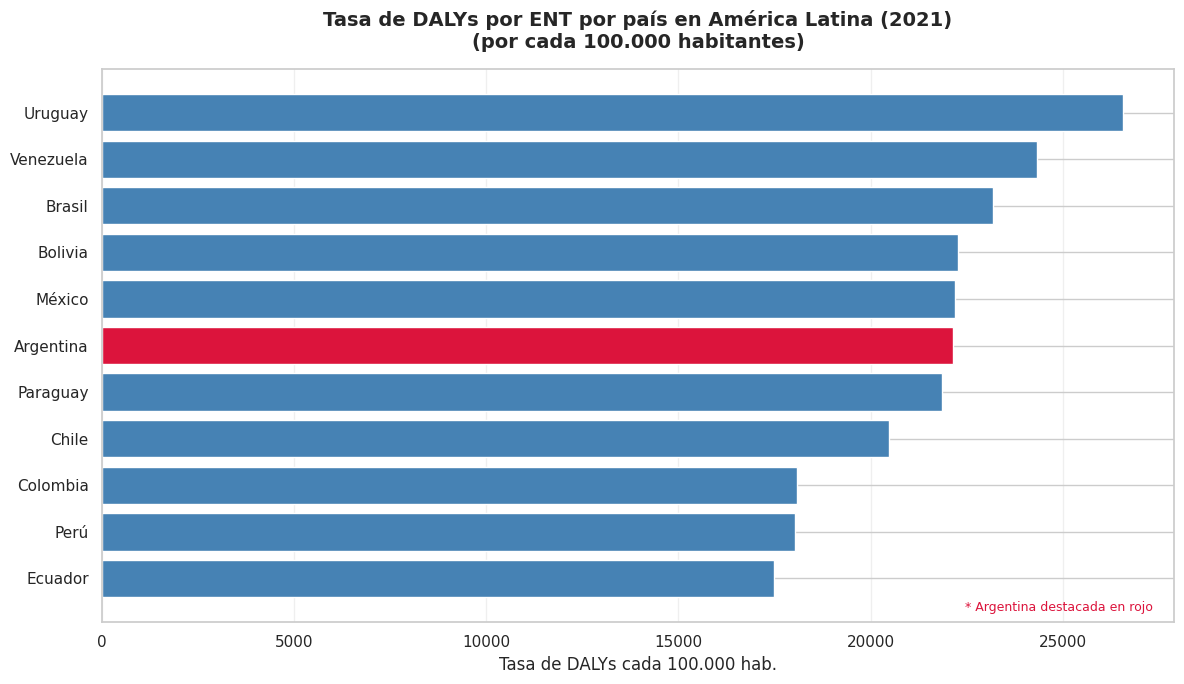


Interpretación: La tasa de DALYs permite comparar países
independientemente de su tamaño poblacional.


In [8]:
# ============================================
# GRÁFICO 3: Ranking de países por carga de ENT (2021)
# ============================================

# Filtrar año 2021, métrica Tasa (para comparar países
# independientemente del tamaño poblacional), causa general
df_paises = df[
    (df['anio'] == 2021) &
    (df['metrica'] == 'Tasa') &
    (df['causa'] == 'Enfermedades que no son contagiosas')
].groupby('pais')['valor'].mean().reset_index()

# Ordenar de mayor a menor
df_paises = df_paises.sort_values('valor', ascending=True)

# Paleta de colores destacando Argentina
colores = ['steelblue' if p != 'Argentina' else 'crimson'
           for p in df_paises['pais']]

# Graficar
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_paises['pais'], df_paises['valor'],
               color=colores, edgecolor='white')

ax.set_title('Tasa de DALYs por ENT por país en América Latina (2021)\n(por cada 100.000 habitantes)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de DALYs cada 100.000 hab.', fontsize=12)
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.3)

# Nota aclaratoria
ax.text(0.98, 0.02, '* Argentina destacada en rojo',
        transform=ax.transAxes, fontsize=9,
        ha='right', color='crimson')

plt.tight_layout()
plt.savefig('grafico3_ranking_paises.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretación: La tasa de DALYs permite comparar países")
print("independientemente de su tamaño poblacional.")

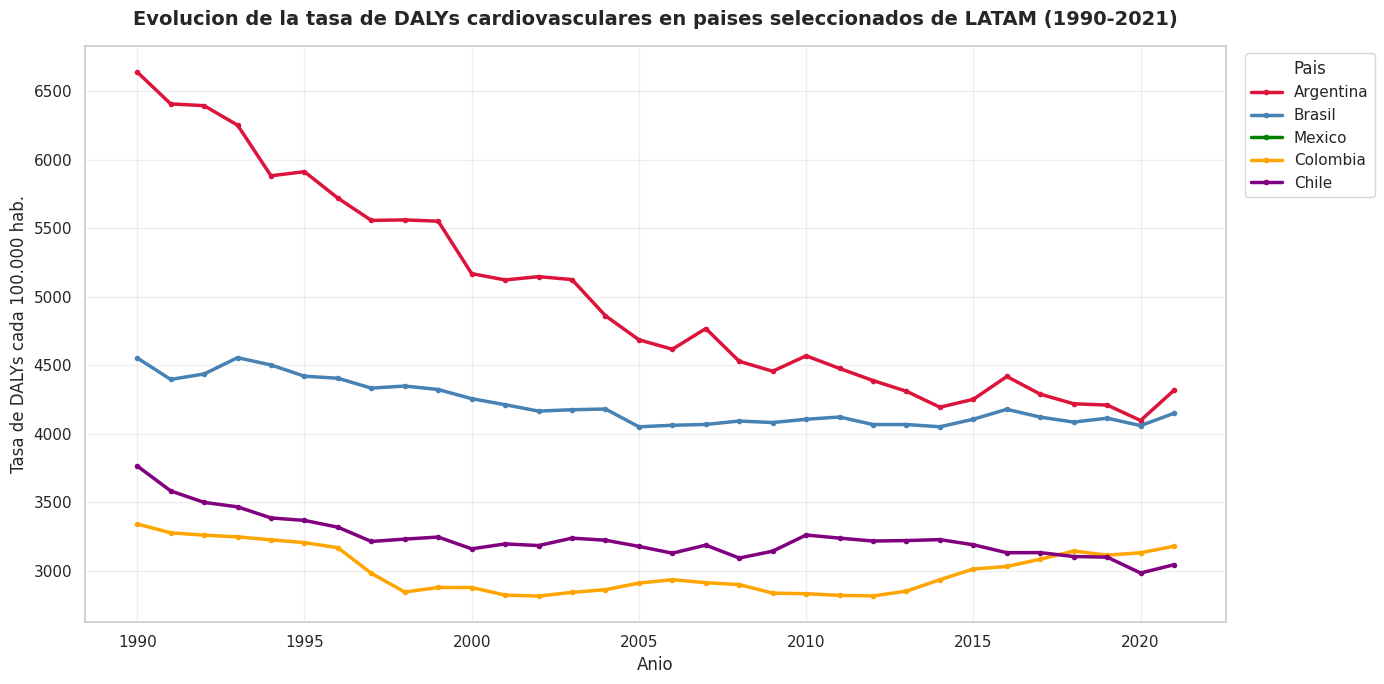

Interpretacion: tendencia de la carga cardiovascular en LATAM


In [10]:
# ============================================
# GRÁFICO 4: Evolución de DALYs cardiovasculares por país
# ============================================

df_cardio = df[
    (df['causa'] == 'Enfermedades cardiovasculares') &
    (df['metrica'] == 'Tasa')
].groupby(['anio', 'pais'])['valor'].mean().reset_index()

paises_principales = ['Argentina', 'Brasil', 'Mexico',
                      'Colombia', 'Chile']
df_cardio = df_cardio[df_cardio['pais'].isin(paises_principales)]

fig, ax = plt.subplots(figsize=(14, 7))

colores_paises = {
    'Argentina': 'crimson',
    'Brasil': 'steelblue',
    'Mexico': 'green',
    'Colombia': 'orange',
    'Chile': 'purple'
}

for pais in paises_principales:
    datos = df_cardio[df_cardio['pais'] == pais]
    ax.plot(datos['anio'], datos['valor'],
            label=pais,
            color=colores_paises[pais],
            linewidth=2.5, marker='o', markersize=3)

ax.set_title('Evolucion de la tasa de DALYs cardiovasculares en paises seleccionados de LATAM (1990-2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Anio', fontsize=12)
ax.set_ylabel('Tasa de DALYs cada 100.000 hab.', fontsize=12)
ax.legend(title='Pais', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico4_cardio_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacion: tendencia de la carga cardiovascular en LATAM")

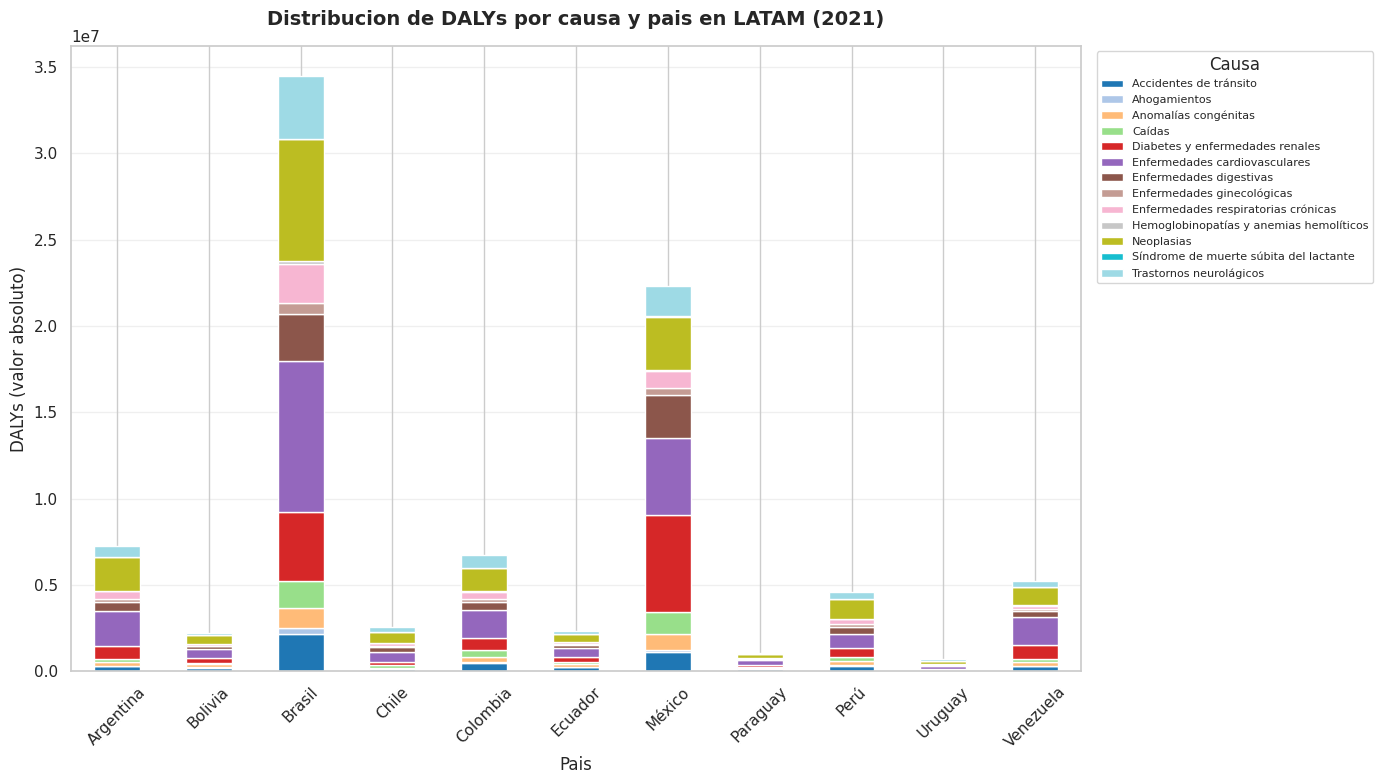

Interpretacion: Brasil y Mexico dominan en valores absolutos
por su mayor poblacion. Las cardiovasculares y neoplasias
son las principales causas en todos los paises.


In [13]:
# ============================================
# GRAFICO 5: Distribucion de causas de ENT por pais (2021)
# ============================================

# Filtrar 2021, metrica Número con tilde, sin categoria general
df_causas = df[
    (df['anio'] == 2021) &
    (df['metrica'] == 'Número') &
    (df['causa'] != 'Enfermedades que no son contagiosas')
].groupby(['pais', 'causa'])['valor'].sum().reset_index()

# Pivot para grafico apilado
df_pivot = df_causas.pivot(index='pais',
                            columns='causa',
                            values='valor').fillna(0)

# Graficar
fig, ax = plt.subplots(figsize=(14, 8))
df_pivot.plot(kind='bar', stacked=True, ax=ax,
              colormap='tab20', edgecolor='white')

ax.set_title('Distribucion de DALYs por causa y pais en LATAM (2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pais', fontsize=12)
ax.set_ylabel('DALYs (valor absoluto)', fontsize=12)
ax.legend(title='Causa', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafico5_causas_paises.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacion: Brasil y Mexico dominan en valores absolutos")
print("por su mayor poblacion. Las cardiovasculares y neoplasias")
print("son las principales causas en todos los paises.")

In [14]:
# ============================================
# GUARDAR DATASET LIMPIO COMO CSV
# ============================================

df.to_csv('gbd_latam_ent_1990_2021.csv', index=False)
print("✓ Dataset limpio guardado como gbd_latam_ent_1990_2021.csv")

# Descargar todos los archivos generados
from google.colab import files

print("\nDescargando archivos...")
files.download('gbd_latam_ent_1990_2021.csv')
files.download('grafico1_evolucion_temporal.png')
files.download('grafico2_argentina_2021.png')
files.download('grafico3_ranking_paises.png')
files.download('grafico4_cardio_evolucion.png')
files.download('grafico5_causas_paises.png')

print("✓ Todos los archivos descargados")

✓ Dataset limpio guardado como gbd_latam_ent_1990_2021.csv

Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Todos los archivos descargados
